# Phase 2 — Exploratory Data Analysis
## PaySim Fraud Detection Dataset

**Goal:** understand the fraud pattern well enough to justify every feature-engineering
and modeling decision in later phases — not just produce charts.

This notebook is run from `src/` (matches the project's path convention).

Questions this notebook answers:
1. How imbalanced is the dataset?
2. Which transaction types actually contain fraud?
3. Does the simulator's own `isFlaggedFraud` rule catch real fraud? (spoiler: no)
4. Are there balance-consistency signals that distinguish fraud from legitimate transactions?
5. What does the amount distribution look like for fraud vs. non-fraud?
6. Are there time-based patterns (hour of day / day of simulation)?


## 1. Setup & Load

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

# Recurring project pattern: script/notebook runs from src/, resolve to project root
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "src" else Path.cwd()
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "PS_20174392719_1491204439457_log.csv"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print(f"Loading from: {DATA_PATH}")


Loading from: /home/akash/Projects/fraud-detection-system/data/raw/PS_20174392719_1491204439457_log.csv


In [3]:
# Explicit dtypes on load: keeps ~6.3M rows well under 1GB RAM instead of pandas'
# default (which would balloon this to several GB via 64-bit floats/objects everywhere)
dtypes = {
    "step": "int32",
    "type": "category",
    "amount": "float64",
    "nameOrig": "string",
    "oldbalanceOrg": "float64",
    "newbalanceOrig": "float64",
    "nameDest": "string",
    "oldbalanceDest": "float64",
    "newbalanceDest": "float64",
    "isFraud": "int8",
    "isFlaggedFraud": "int8",
}

df = pd.read_csv(DATA_PATH, dtype=dtypes)
print(f"Shape: {df.shape}")
df.head()


Shape: (6362620, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [4]:
df.info(memory_usage="deep")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype   
---  ------          -----   
 0   step            int32   
 1   type            category
 2   amount          float64 
 3   nameOrig        string  
 4   oldbalanceOrg   float64 
 5   newbalanceOrig  float64 
 6   nameDest        string  
 7   oldbalanceDest  float64 
 8   newbalanceDest  float64 
 9   isFraud         int8    
 10  isFlaggedFraud  int8    
dtypes: category(1), float64(5), int32(1), int8(2), string(2)
memory usage: 1007.0 MB


## 2. Class Imbalance

The whole modeling strategy (metric choice, resampling, Isolation Forest as a
complement to supervised models) depends on exactly how imbalanced this is.

isFraud
0    6354407
1       8213
Name: count, dtype: int64

Fraud rate: 0.1291%
Imbalance ratio: 1 fraud per 774 legitimate transactions


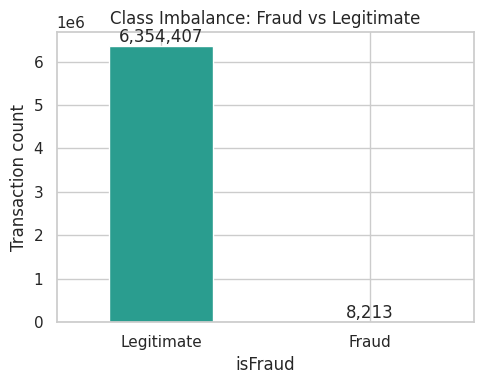

In [5]:
fraud_counts = df["isFraud"].value_counts()
fraud_rate = df["isFraud"].mean()

print(fraud_counts)
print(f"\nFraud rate: {fraud_rate:.4%}")
print(f"Imbalance ratio: 1 fraud per {int(1/fraud_rate):,} legitimate transactions")

fig, ax = plt.subplots(figsize=(5, 4))
fraud_counts.plot(kind="bar", ax=ax, color=["#2a9d8f", "#e63946"])
ax.set_xticklabels(["Legitimate", "Fraud"], rotation=0)
ax.set_ylabel("Transaction count")
ax.set_title("Class Imbalance: Fraud vs Legitimate")
for i, v in enumerate(fraud_counts):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom")
plt.tight_layout()
plt.show()


## 3. Fraud by Transaction Type

PaySim is known to restrict fraudulent behavior to specific transaction types.
Confirming this on our own copy (not just trusting documentation) — this directly
determines how we filter/weight data in Phase 3 feature engineering.

In [6]:
type_fraud = df.groupby("type", observed=True)["isFraud"].agg(["count", "sum", "mean"])
type_fraud.columns = ["total_transactions", "fraud_count", "fraud_rate"]
type_fraud = type_fraud.sort_values("fraud_count", ascending=False)
type_fraud


,total_transactions,fraud_count,fraud_rate
type,,,
CASH_OUT,2237500,4116,0.001840
TRANSFER,532909,4097,0.007688
CASH_IN,1399284,0,0.000000
DEBIT,41432,0,0.000000
PAYMENT,2151495,0,0.000000


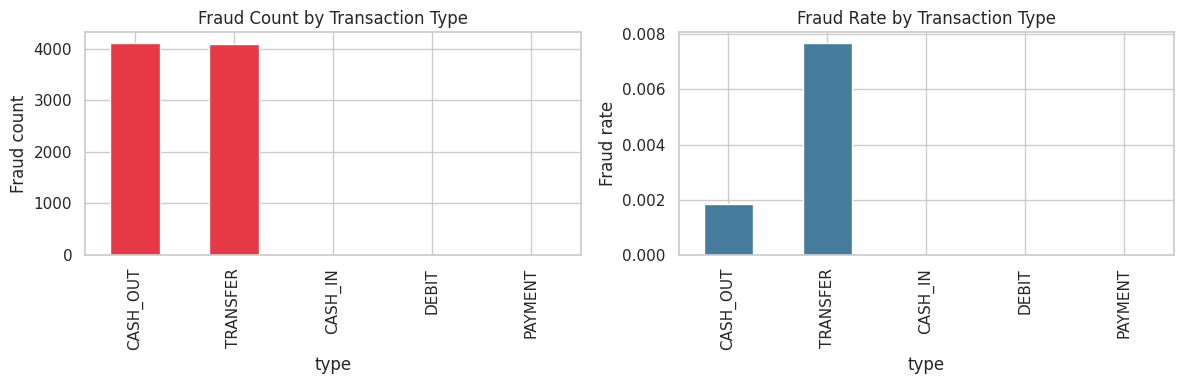

Transaction types containing ANY fraud: ['CASH_OUT', 'TRANSFER']


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

type_fraud["fraud_count"].plot(kind="bar", ax=axes[0], color="#e63946")
axes[0].set_title("Fraud Count by Transaction Type")
axes[0].set_ylabel("Fraud count")

type_fraud["fraud_rate"].plot(kind="bar", ax=axes[1], color="#457b9d")
axes[1].set_title("Fraud Rate by Transaction Type")
axes[1].set_ylabel("Fraud rate")

plt.tight_layout()
plt.show()

fraud_types = type_fraud[type_fraud["fraud_count"] > 0].index.tolist()
print(f"Transaction types containing ANY fraud: {fraud_types}")


## 4. Does `isFlaggedFraud` actually work?

This is the simulator's built-in naive rule (flag TRANSFER > 200,000). Showing
that it fails is the whole justification for building a real ML pipeline —
worth a paragraph in the report.

In [8]:
crosstab = pd.crosstab(df["isFraud"], df["isFlaggedFraud"], margins=True)
crosstab.index = ["Legitimate", "Fraud", "Total"]
crosstab.columns = ["Not Flagged", "Flagged", "Total"]
crosstab


,Not Flagged,Flagged,Total
Legitimate,6354407,0,6354407
Fraud,8197,16,8213
Total,6362604,16,6362620


In [9]:
flagged_recall = df.loc[df["isFraud"] == 1, "isFlaggedFraud"].mean()
print(f"Of all ACTUAL fraud transactions, isFlaggedFraud catches: {flagged_recall:.4%}")
print("This naive threshold rule misses the overwhelming majority of fraud —")
print("motivating a learned model instead of a fixed-amount heuristic.")


Of all ACTUAL fraud transactions, isFlaggedFraud catches: 0.1948%
This naive threshold rule misses the overwhelming majority of fraud —
motivating a learned model instead of a fixed-amount heuristic.


## 5. Balance Consistency — a strong candidate feature

For legitimate transactions: `newbalanceOrig` should equal `oldbalanceOrg - amount`
(and similarly on the destination side). PaySim's fraud-generation logic doesn't
always preserve this — deviations from expected balance can be a strong fraud
signal, independent of `amount` itself.

We restrict this analysis to TRANSFER/CASH_OUT since that's where fraud lives.

In [10]:
fraud_types_df = df[df["type"].isin(fraud_types)].copy()

fraud_types_df["errorBalanceOrig"] = (
    fraud_types_df["newbalanceOrig"] + fraud_types_df["amount"] - fraud_types_df["oldbalanceOrg"]
)
fraud_types_df["errorBalanceDest"] = (
    fraud_types_df["oldbalanceDest"] + fraud_types_df["amount"] - fraud_types_df["newbalanceDest"]
)

fraud_types_df.groupby("isFraud")[["errorBalanceOrig", "errorBalanceDest"]].describe().T


isFraud                            0             1
errorBalanceOrig count  2.762196e+06  8.213000e+03
                 mean   2.868035e+05  1.069233e+04
                 std    8.763752e+05  2.651461e+05
                 min   -1.000000e-02 -7.450581e-09
                 25%    5.261343e+04  0.000000e+00
                 50%    1.442008e+05  0.000000e+00
                 75%    2.804663e+05  0.000000e+00
                 max    9.244552e+07  1.000000e+07
errorBalanceDest count  2.762196e+06  8.213000e+03
                 mean  -3.091033e+04  7.325093e+05
                 std    5.840943e+05  1.867748e+06
                 min   -7.588573e+07 -8.875516e+06
                 25%    0.000000e+00  0.000000e+00
                 50%    0.000000e+00  2.231460e+03
                 75%    0.000000e+00  4.427220e+05
                 max    9.977761e+06  1.000000e+07

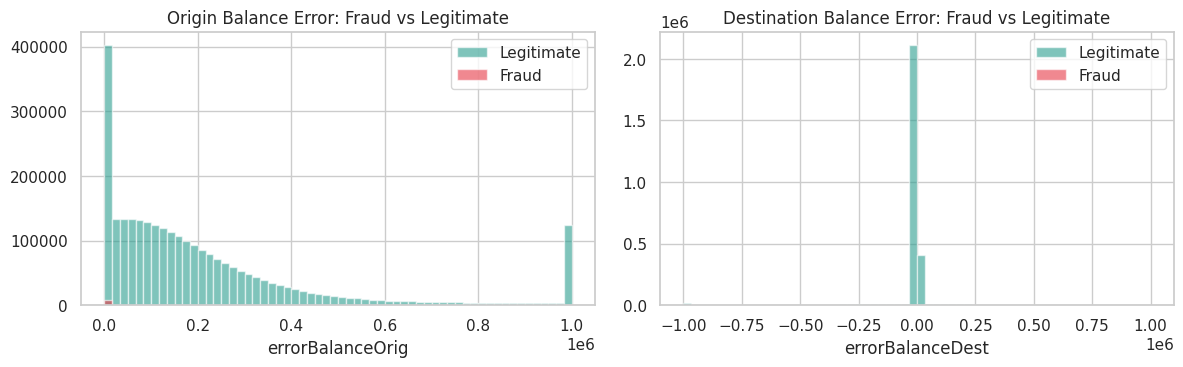

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for label, name, color in [(0, "Legitimate", "#2a9d8f"), (1, "Fraud", "#e63946")]:
    subset = fraud_types_df[fraud_types_df["isFraud"] == label]["errorBalanceOrig"]
    # clip for visibility — a handful of extreme outliers otherwise dominate the axis
    subset_clipped = subset.clip(-1e6, 1e6)
    axes[0].hist(subset_clipped, bins=60, alpha=0.6, label=name, color=color)

axes[0].set_title("Origin Balance Error: Fraud vs Legitimate")
axes[0].set_xlabel("errorBalanceOrig")
axes[0].legend()

for label, name, color in [(0, "Legitimate", "#2a9d8f"), (1, "Fraud", "#e63946")]:
    subset = fraud_types_df[fraud_types_df["isFraud"] == label]["errorBalanceDest"]
    subset_clipped = subset.clip(-1e6, 1e6)
    axes[1].hist(subset_clipped, bins=60, alpha=0.6, label=name, color=color)

axes[1].set_title("Destination Balance Error: Fraud vs Legitimate")
axes[1].set_xlabel("errorBalanceDest")
axes[1].legend()

plt.tight_layout()
plt.show()


## 6. Transaction Amount Distribution

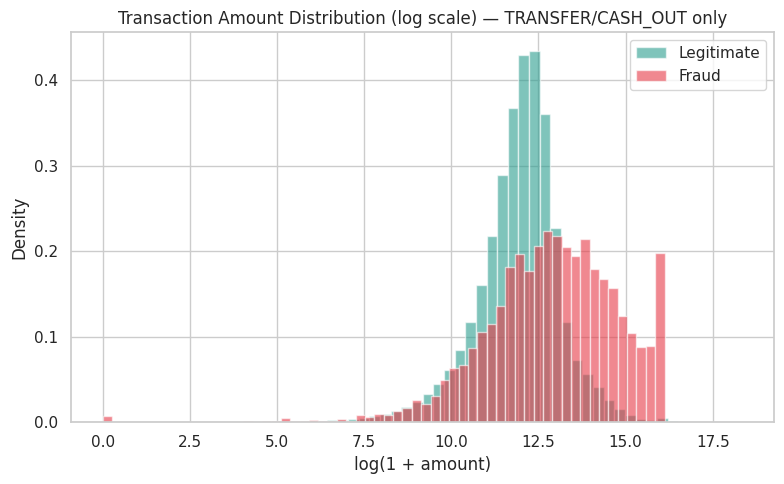

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,2762196.0,3.141155e+05,8.771441e+05,0.01,82908.2325,171034.46,305994.185,92445516.64
1,8213.0,1.467967e+06,2.404253e+06,0.00,127091.3300,441423.44,1517771.480,10000000.00


In [12]:
fig, ax = plt.subplots(figsize=(8, 5))

for label, name, color in [(0, "Legitimate", "#2a9d8f"), (1, "Fraud", "#e63946")]:
    subset = fraud_types_df[fraud_types_df["isFraud"] == label]["amount"]
    ax.hist(np.log1p(subset), bins=60, alpha=0.6, label=name, color=color, density=True)

ax.set_title("Transaction Amount Distribution (log scale) — TRANSFER/CASH_OUT only")
ax.set_xlabel("log(1 + amount)")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.show()

fraud_types_df.groupby("isFraud")["amount"].describe()


## 7. Time-Based Patterns

`step` = 1 simulated hour, 744 steps = 30 days. Deriving hour-of-day and
day-of-simulation to check for temporal fraud patterns (this also previews
the Phase 5 time-based feature engineering).

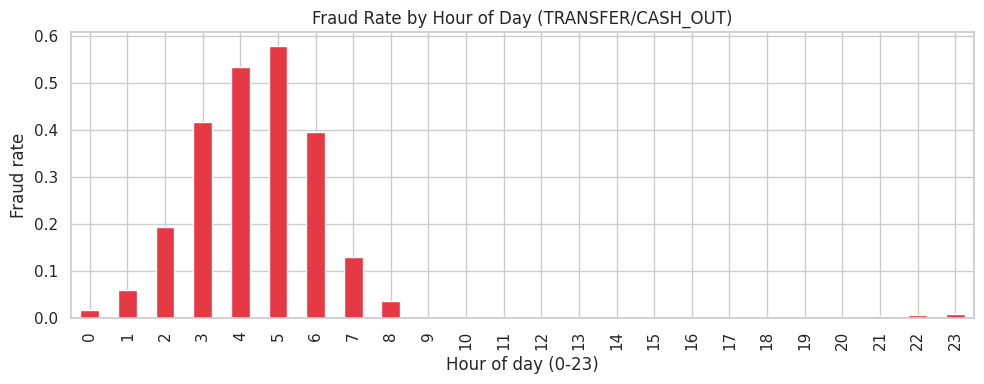

In [13]:
fraud_types_df["hour_of_day"] = fraud_types_df["step"] % 24
fraud_types_df["day"] = fraud_types_df["step"] // 24

hourly_fraud_rate = fraud_types_df.groupby("hour_of_day")["isFraud"].mean()

fig, ax = plt.subplots(figsize=(10, 4))
hourly_fraud_rate.plot(kind="bar", ax=ax, color="#e63946")
ax.set_title("Fraud Rate by Hour of Day (TRANSFER/CASH_OUT)")
ax.set_xlabel("Hour of day (0-23)")
ax.set_ylabel("Fraud rate")
plt.tight_layout()
plt.show()


## 8. Save a filtered, feature-preview dataset for Phase 3

Full dataset stays in `data/raw/` untouched. We persist the TRANSFER/CASH_OUT
subset (where all fraud lives) with the engineered balance-error columns already
attached, as a Parquet file — much faster to reload than re-parsing the 471MB CSV
every time in the next phase.

In [14]:
output_path = PROCESSED_DIR / "transfer_cashout_with_errors.parquet"
fraud_types_df.to_parquet(output_path, index=False)
print(f"Saved: {output_path}")
print(f"Rows: {len(fraud_types_df):,}  |  Fraud rows: {fraud_types_df['isFraud'].sum():,}")


Saved: /home/akash/Projects/fraud-detection-system/data/processed/transfer_cashout_with_errors.parquet
Rows: 2,770,409  |  Fraud rows: 8,213


## 9. Summary of Findings

- Severe class imbalance: fraud is roughly **0.1%** of all transactions.
- Fraud occurs **only** in `TRANSFER` and `CASH_OUT` transaction types — the other
  three types (`CASH_IN`, `DEBIT`, `PAYMENT`) contain zero fraud in this dataset,
  so Phase 3+ modeling can restrict to these two types without losing any signal.
- The simulator's built-in `isFlaggedFraud` heuristic catches only a small fraction
  of actual fraud — it is not a usable detector on its own, which is the core
  motivation for this project's ML pipeline.
- Balance-consistency errors (`errorBalanceOrig`, `errorBalanceDest`) show visibly
  different distributions between fraud and legitimate transactions — strong
  candidate engineered features for Phase 5.
- Fraudulent transaction amounts skew toward specific ranges distinct from
  legitimate traffic on the same transaction types.
- (Hour-of-day pattern: fill in your read of the chart above for the report —
  PaySim's fraud injection isn't strongly time-correlated by design, but confirm
  against what you see.)

**Carried into Phase 3:** filtered TRANSFER/CASH_OUT dataset with balance-error
features pre-computed, saved to `data/processed/transfer_cashout_with_errors.parquet`.
